In [24]:
library(dplyr)       # for data manipulation
library(ggplot2)     # for data visualization
library(stringr)     # for string functionality
library(cluster)     # for general clustering algorithms
library(factoextra)  # for visualizing cluster results
library(readr)      # for reading

In [61]:
# read dataset and clean
df <- read_csv("data/merged_county_data.csv")
county <- df$County
df <- df %>% filter(!County %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"))
df_raw <- df
df$density <- df$population*1.0/df$AREA_SQMI
df <- df %>% select(-c("County", "PHR", "outbreak", "AREA_SQMI"), -starts_with("M_"), -starts_with("MP_"), -starts_with("E_"), -starts_with("EPL_"), -starts_with("SPL_"), -starts_with("RPL_"), -starts_with("F_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% select(-c("EP_MINRTY", "EP_HISP", "EP_AFAM", "EP_POV150", "EP_UNINSUR"))
df <- as.data.frame(scale(df))  

Rows: 254 Columns: 165
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (163): cve, outbreak, enrollment, population, PHR, pct_hispanic, pct_bla...
lgl   (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


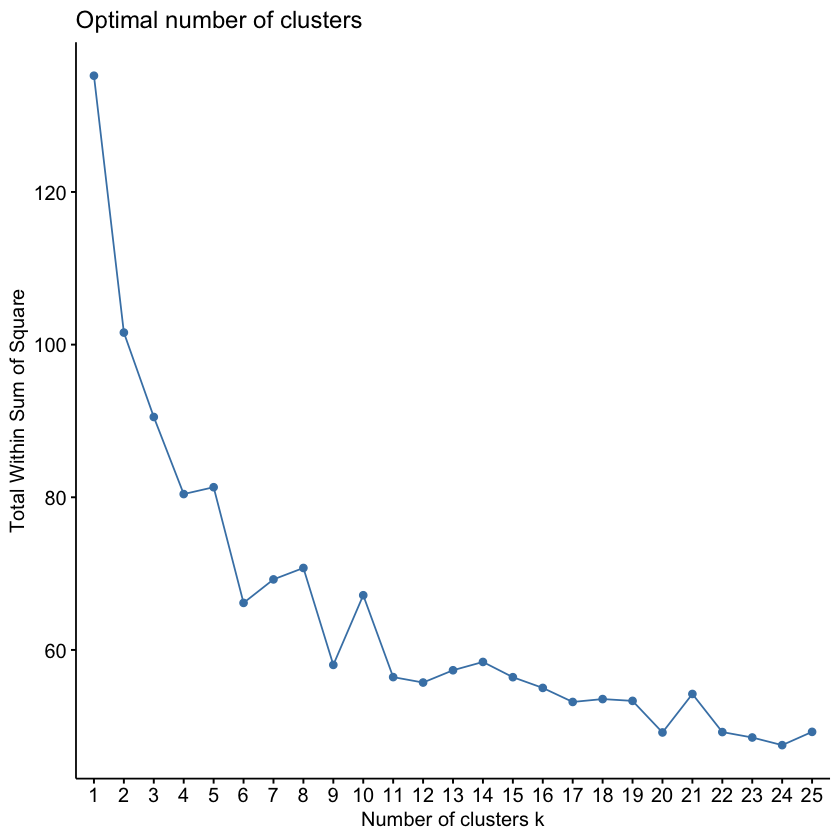

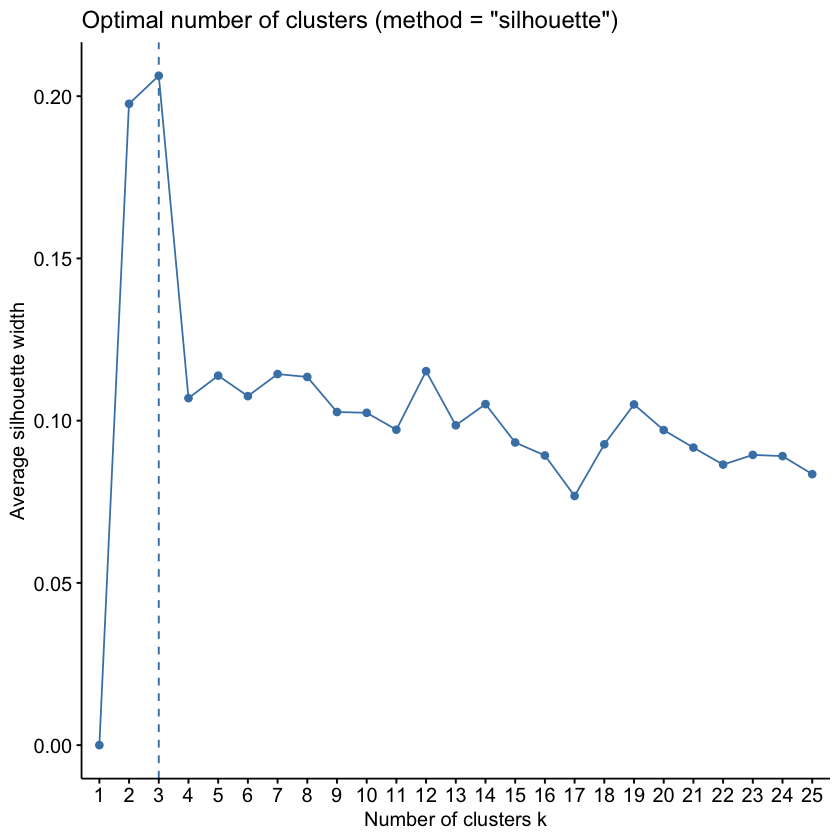

In [62]:
# inspect optimal clusters
fviz_nbclust(
  df,
  kmeans, 
  k.max = 25,
  method = "wss",
  diss = get_dist(df, method = "spearman")
)

fviz_nbclust(
  df, 
  kmeans, 
  method = "silhouette", 
  k.max = 25, 
  nstart = 25)

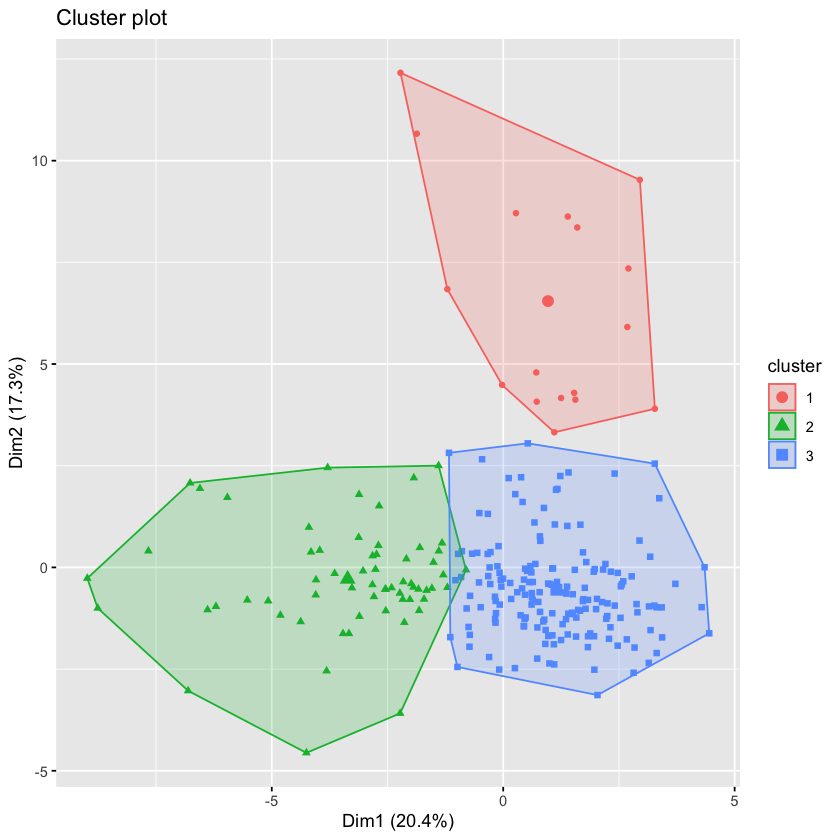

In [77]:
set.seed(100)
km <- kmeans(df, centers = 3, nstart = 25)
fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex")

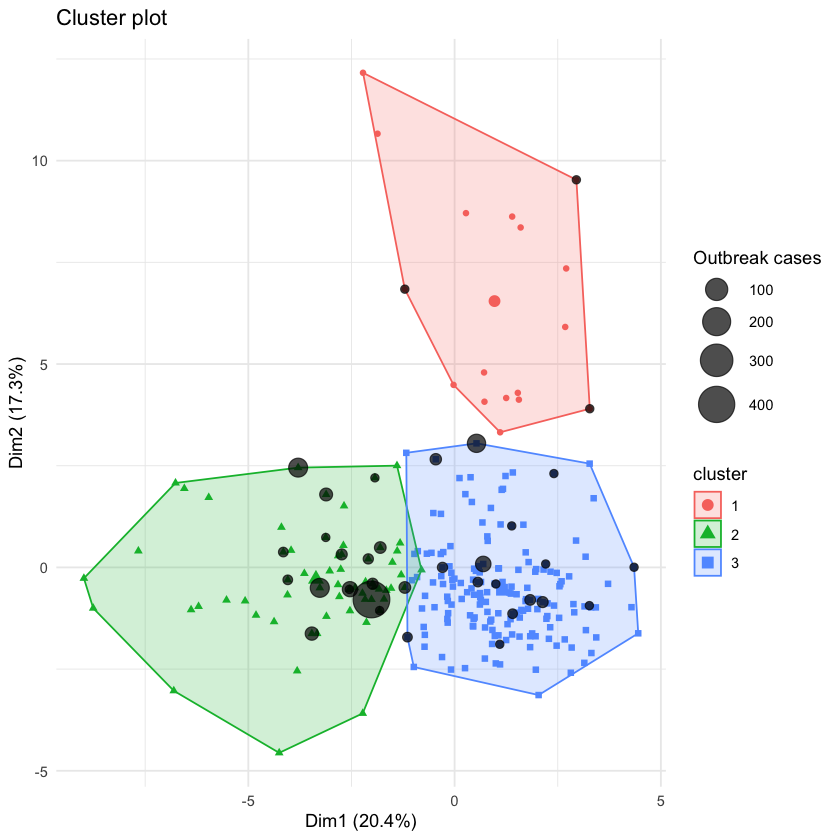

In [78]:
# get PCA coords
pca_coords <- as.data.frame(pca_out$x[, 1:2])
pca_coords$cluster <- factor(km$cluster)
pca_coords$outbreak <- df_raw$outbreak  # raw outbreak count

p <- fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex") +
  theme_minimal()

# extract the PCA coords fviz already computed
plot_data <- p$data

# add outbreak from df_raw (make sure row order matches)
plot_data$outbreak <- df_raw$outbreak

# rebuild with sized points on top
p + 
  geom_point(data = plot_data %>% filter(outbreak > 0),
             aes(x = x, y = y, size = outbreak),
             color = "black", alpha = 0.7) +
  scale_size_continuous(range = c(2, 10), name = "Outbreak cases")

In [79]:
# see what loads heavily on PC1
pca_out <- prcomp(df)
names(pca_out)
sort(pca_out$rotation[, 1], decreasing = TRUE) %>% head(10)
sort(pca_out$rotation[, 1], decreasing = FALSE) %>% head(10)

[1] "sdev"     "rotation" "center"   "scale"    "x"

pct_white          cve     EP_AGE65  pct_college   EP_TWOMORE    EP_DISABL 
  0.33481873   0.21088536   0.20045796   0.19570852   0.16563618   0.05428499 
    EP_ASIAN    pct_black EP_OTHERRACE      EP_NHPI 
  0.03485572   0.03228008   0.03203957   0.01849488

pct_hispanic     EP_NOHSDP     EP_LIMENG pct_uninsured   pct_poverty 
   -0.3603811    -0.3380666    -0.3043091    -0.2692743    -0.2656737 
    EP_SNGPNT      EP_CROWD      EP_AGE17      EP_NOVEH      EP_NOINT 
   -0.2422412    -0.2348407    -0.2077236    -0.1987022    -0.1791407